In [1]:
# this deals with extrapolation
# - say we have stock price with clear trends upwards
# - hence train data will lower values and test data will have higher values
# - goal of this lab is to see if using just the prices in train set, can the ml model predict the upward trend in the test set or do we have to use something like "log returns" for this ?

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from mpl_toolkits.mplot3d import Axes3D

from sklearn.svm import SVR
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor

# double cos function

In [3]:
# Making Dataset
N = 1000
X = np.random.random((N,2)) * 6 - 3 # uniform distribution ranging from -3 to +3
Y = np.cos(2*X[:,0]) + np.cos(3*X[:,1])

In [4]:
# plt.plot(X[:,1]);

In [5]:
'''Y is a linear function of transformed features, transformation is cosine of 2 features '''

'Y is a linear function of transformed features, transformation is cosine of 2 features '

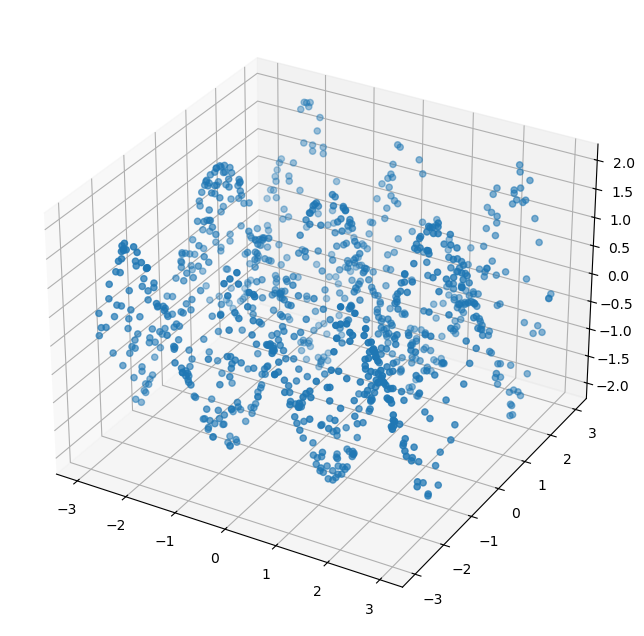

In [6]:
fig = plt.figure(figsize = (20,8))
ax = fig.add_subplot(111, projection ='3d')
ax.scatter(X[:,1], X[:,0], Y);

In [8]:
#SVR
model = SVR(C=100.) # c is hyperparameter which balances the omount of regularization 
model.fit(X,Y);

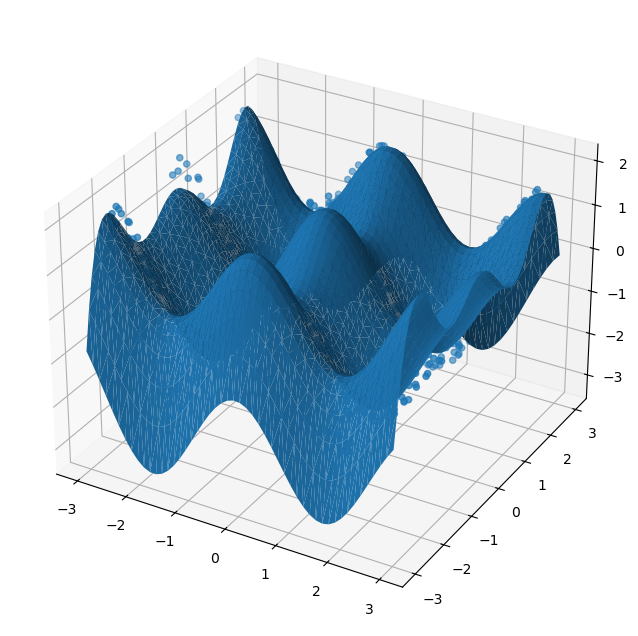

In [11]:
# plot the prediction surface
fig = plt.figure(figsize =(20,8))
ax = fig.add_subplot(111, projection = '3d')
ax.scatter(X[:,0], X[:,1], Y)

#surface plot
line = np.linspace(-3,3,50) # range of the plot is -3 to +3
xx, yy = np.meshgrid(line, line)
Xgrid = np.vstack((xx.flatten(), yy.flatten())).T
Yhat = model.predict(Xgrid).flatten()
ax.plot_trisurf(Xgrid[:,0], Xgrid[:,1], Yhat, linewidth=0.2, antialiased=True);

In [12]:
''' model seems to do a good job in the training dataset since x1, x2 both ranges from -3 to +3'''

' model seems to do a good job in the training dataset since x1, x2 both ranges from -3 to +3'

In [13]:
''' below code to see if the model can extrapolate to the inputs beyond -3 to +3 which was not in the training set'''

' below code to see if the model can extrapolate to the inputs beyond -3 to +3 which was not in the training set'

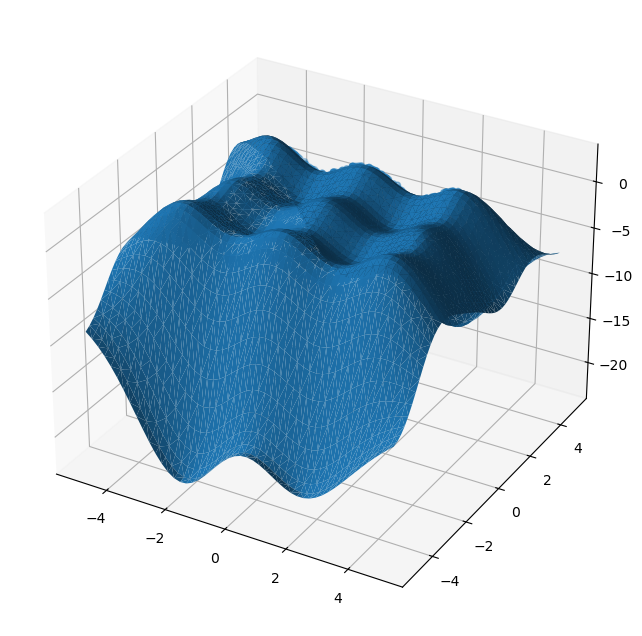

In [18]:
# can it extrapolate?
# plot the prediction surface
fig = plt.figure(figsize =(20,8))
ax = fig.add_subplot(111, projection = '3d')
ax.scatter(X[:,0], X[:,1], Y)

#surface plot
line = np.linspace(-5,5,50) # range of the plot is -5 to +5 # this is changed now beyond the training data 
xx, yy = np.meshgrid(line, line)
Xgrid = np.vstack((xx.flatten(), yy.flatten())).T
Yhat = model.predict(Xgrid).flatten()
ax.plot_trisurf(Xgrid[:,0], Xgrid[:,1], Yhat, linewidth=0.2, antialiased=True)
plt.show();

In [20]:
'''model not extrapolating well when we extend the range of value
below plot shows the true function and it clearly shows that the above plot (extrapolated) is quite diff from the correct function'''

'model not extrapolating well when we extend the range of value\nbelow plot shows the true function and it clearly shows that the above plot (extrapolated) is quite diff from the correct function'

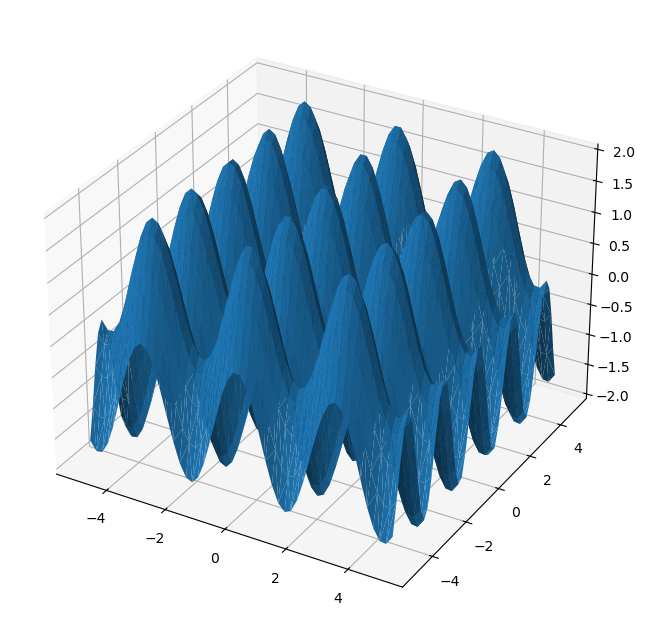

In [21]:
#what the true function looks like??

# can it extrapolate?
# plot the prediction surface
fig = plt.figure(figsize =(20,8))
ax = fig.add_subplot(111, projection = '3d')
# ax.scatter(X[:,0], X[:,1], Y)

#surface plot
line = np.linspace(-5,5,50) # range of the plot is -5 to +5 # this is changed now beyond the training data 
xx, yy = np.meshgrid(line, line)
Xgrid = np.vstack((xx.flatten(), yy.flatten())).T
Ytrue = np.cos(2*Xgrid[:,0]) + np.cos(3*Xgrid[:,1])
ax.plot_trisurf(Xgrid[:,0], Xgrid[:,1], Ytrue, linewidth=0.2, antialiased=True)
plt.show();

In [22]:
# checking how random forest would extrapolate

In [23]:
model= RandomForestRegressor()
model.fit(X,Y);

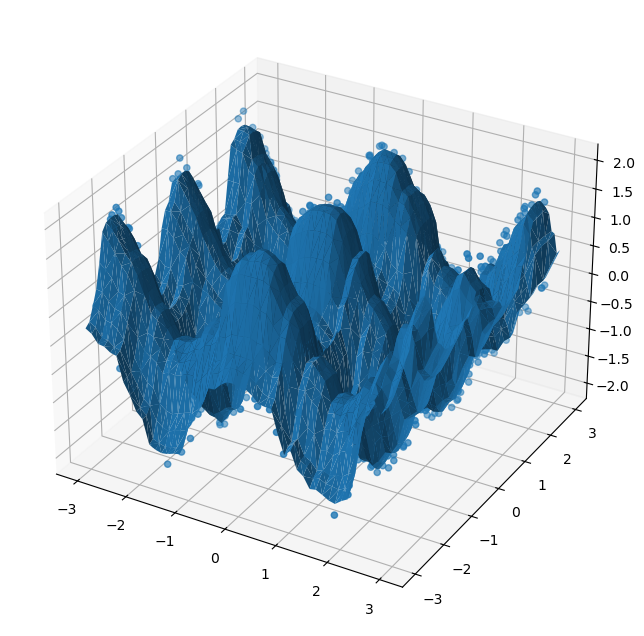

In [28]:
# plot the prediction surface
fig = plt.figure(figsize = (20,8))
ax = fig.add_subplot(111, projection = '3d')
ax.scatter(X[:,0], X[:,1], Y)

#surface plot
line = np.linspace(-3,3,50)
xx, yy = np.meshgrid(line, line)
Xgrid = np.vstack((xx.flatten(), yy.flatten())).T
Yhat = model.predict(Xgrid).flatten()
ax.plot_trisurf(Xgrid[:,0], Xgrid[:,1], Yhat, linewidth=0.2, antialiased=True);

In [29]:
''' bumpy and jagged predictions in randomforrest- since randomforest is just the average of bunch of decision trees '''

' bumpy and jagged predictions in randomforrest- since randomforest is just the average of bunch of decision trees '

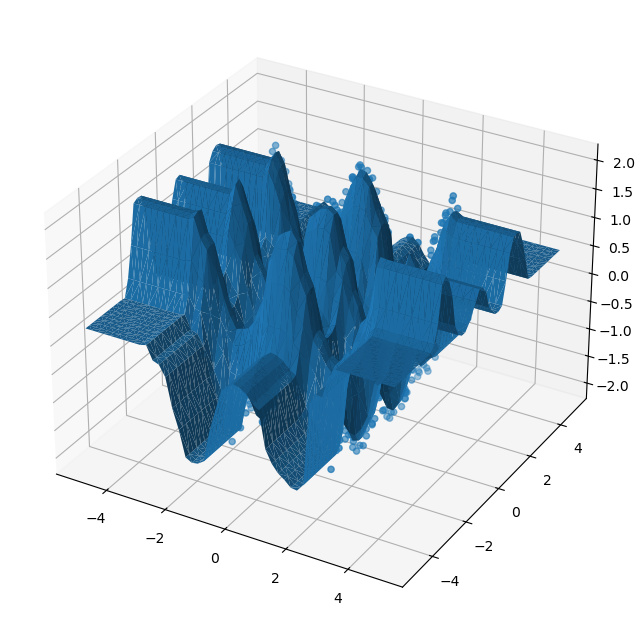

In [31]:
# "can it extrapolate?
# plot the prediction surface
fig = plt.figure(figsize = (20,8))
ax = fig.add_subplot(111, projection = '3d')
ax.scatter(X[:,0], X[:,1], Y)

#surface plot
line = np.linspace(-5,5,50) # just the range of the values is expanded 
xx, yy = np.meshgrid(line, line)
Xgrid = np.vstack((xx.flatten(), yy.flatten())).T
Yhat = model.predict(Xgrid).flatten()
ax.plot_trisurf(Xgrid[:,0], Xgrid[:,1], Yhat, linewidth=0.2, antialiased=True);

In [32]:
'''random forest just projects outwards the last known predictions since no more decision values beyond the training values ,
and we know that decision trees learn horizontal lines'''

'random forest just projects outwards the last known predictions since no more decision values beyond the training values ,\nand we know that decision trees learn horizontal lines'

In [33]:
##deep learning called MLP regressor - in scikit learn, it is called multi layer perceptron
model = MLPRegressor(hidden_layer_sizes = 128, alpha = 0., learning_rate_init = 0.01)
model.fit(X,Y);

C:\Users\VARUN\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


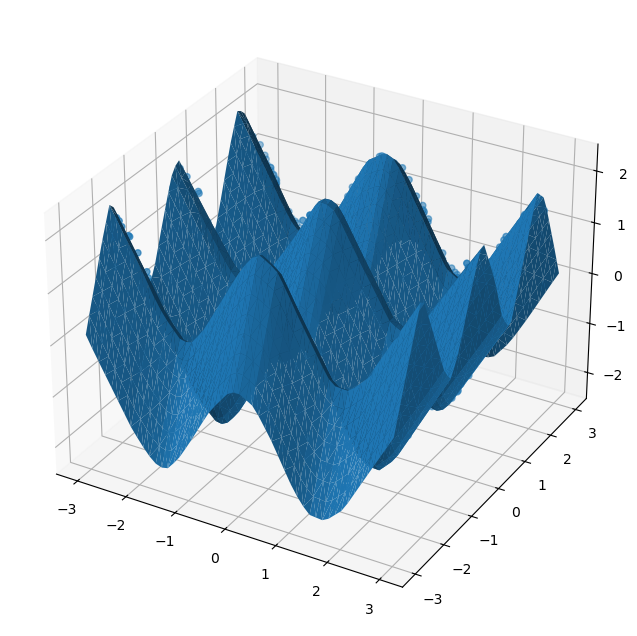

In [34]:
# plot the prediction surface
fig = plt.figure(figsize = (20,8))
ax = fig.add_subplot(111, projection = '3d')
ax.scatter(X[:,0], X[:,1], Y)

#surface plot
line = np.linspace(-3,3,50) # just the range of the values is expanded 
xx, yy = np.meshgrid(line, line)
Xgrid = np.vstack((xx.flatten(), yy.flatten())).T
Yhat = model.predict(Xgrid).flatten()
ax.plot_trisurf(Xgrid[:,0], Xgrid[:,1], Yhat, linewidth=0.2, antialiased=True);

In [35]:
'''seems to fit pretty well, best fit yet'''

'seems to fit pretty well, best fit yet'

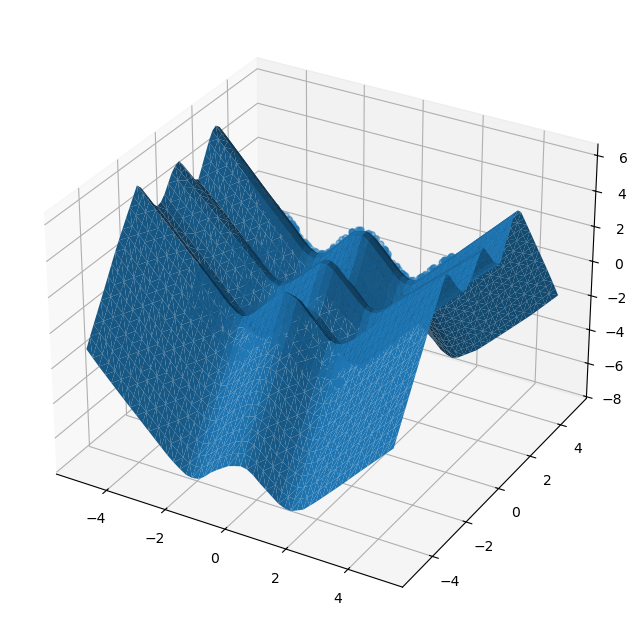

In [36]:
# can it extrapolate?
# plot the prediction surface
fig = plt.figure(figsize = (20,8))
ax = fig.add_subplot(111, projection = '3d')
ax.scatter(X[:,0], X[:,1], Y)

#surface plot
line = np.linspace(-5,5,50) # just the range of the values is expanded 
xx, yy = np.meshgrid(line, line)
Xgrid = np.vstack((xx.flatten(), yy.flatten())).T
Yhat = model.predict(Xgrid).flatten()
ax.plot_trisurf(Xgrid[:,0], Xgrid[:,1], Yhat, linewidth=0.2, antialiased=True);

In [37]:
''' neural network simply extends the prediction out in the straight line'''

' neural network simply extends the prediction out in the straight line'

### Conclusion: we have seen some of the most powerful models and seen that they completely fait at the task of extrapolation

# stock prices

In [6]:
import pandas as pd
import os
os.chdir(r'G:\My Drive\Study\Time Series Analysis Udemy\Data\time series analysis forecasting')

In [7]:
df = pd.read_csv('SPY.csv', index_col = 'Date', parse_dates = True)

In [8]:
df.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2010-01-04,112.370003,113.389999,111.510002,113.330002,92.246048,118944600
2010-01-05,113.260002,113.680000,112.849998,113.629997,92.490204,111579900
2010-01-06,113.519997,113.989998,113.430000,113.709999,92.555328,116074400
2010-01-07,113.500000,114.330002,113.180000,114.190002,92.946060,131091100
2010-01-08,113.889999,114.620003,113.660004,114.570000,93.255348,126402800


In [9]:
df.shape

(2263, 6)

In [10]:
train = df.iloc[:2000]['Close'].to_numpy()
test = df.iloc[2000:]['Close'].to_numpy()

In [12]:
'''building autoregressive model with 2 lags - dependent on last 2 time steps'''

'building autoregressive model with 2 lags - dependent on last 2 time steps'

In [13]:
Xtrain = []
for t in range(len(train)-1):
    x0 = train[t]
    x1 = train[t+1]
    Xtrain.append((x0,x1))
    
Xtest = []
for t in range(len(test)-1):
    x0 = test[t]
    x1 = test[t+1]
    Xtest.append((x0,x1))    

In [17]:
len(Xtrain)

1999

In [19]:
type(Xtrain)

list

In [20]:
Xtrain = np.array(Xtrain)
Xtest = np.array(Xtest)

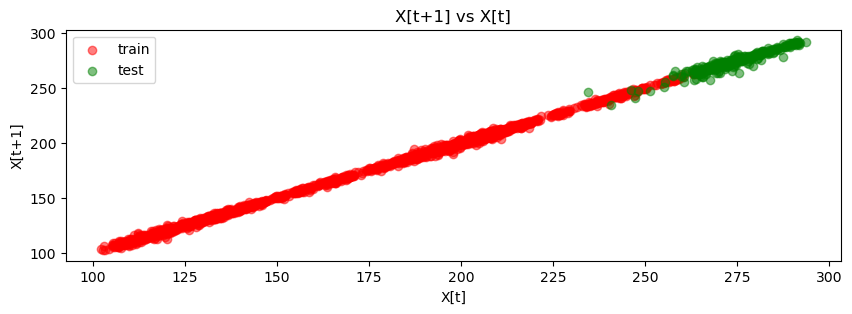

In [24]:
plt.figure(figsize = (10,3))
plt.xlabel('X[t]')
plt.ylabel('X[t+1]')
plt.title('X[t+1] vs X[t]')
plt.scatter(Xtrain[:,0], Xtrain[:,1], c='r', alpha = 0.5, label ='train')
plt.scatter(Xtest[:,0], Xtest[:,1], c='g', alpha = 0.5, label ='test')
plt.legend();

In [27]:
''' train and test space occupy a completely diff area of the input space'''
'''45 degree line since t and t+1 prices would approximately be the same only'''
''' model will be trained only on the res values, green values will never be observed'''

' model will be trained only on the res values, green values will never be observed'

In [28]:
'''scaling will also not help, it will still show the test values higher than the train values in the scaled down version'''

'scaling will also not help, it will still show the test values higher than the train values in the scaled down version'

### Conclusion - '''ML will not be able to extrapolate the data as observed in the double cos function curve'''